# Train

## Importok

A szükséges könyvtárak betöltése:

1. Használt modellek: RandomForestRegressor, HistGradientBoostingRegressor, LGBMRegressor, XGBRegressor, Ridge
2. Pipeline: scikit-learn pipeline lehetőség
3. SimpleImputer: Ridge-nél a NAN-ok kezelésére
4. pandas, numpy: adatkezelés
5. joblib: adatmentés, betöltés
6. sklearn.metrics: metrikákhoz
7. matplotlib: vizualizáció
8. os: fájl meglétének ellenőrzéséhez

In [1]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt

import os

## Adat és artifactok betöltése

In [2]:
train = pd.read_parquet("../data/preprocessed/train.parquet")
test  = pd.read_parquet("../data/preprocessed/test.parquet")
FEATURES = joblib.load("../artifacts/features.pkl")
LOCATION_MAPPING = joblib.load("../artifacts/location_mapping.pkl")
ENSEMBLE_PATH = "../models/models_ensemble.pkl"

## Target létrehozás

In [3]:
train = train.sort_values(["location", train.index.name])
test  = test.sort_values(["location", test.index.name])

train["pm25_next"] = train.groupby("location")["pm25"].shift(-1)
test["pm25_next"]  = test.groupby("location")["pm25"].shift(-1)

TARGET = "pm25_next"

## NAN-ok törlése

In [4]:
columns = [
    "pm25_next",
    "pm25_lag1",
    "pm25_lag3",
    "pm25_lag6",
    "pm25_lag24",
    "pm25_roll6",
    "pm25_roll24",
    "pm25_trend_3h",
    "pm25_std_12h",
    "temp_change_3h",
    "humidity_change_3h",
    "wind_change_3h",
    "stagnation_hours_6h"
]

train = train.dropna(subset=columns)
test  = test.dropna(subset=columns)

## Train és teszt adatok létrehozása

In [5]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

A célváltozót logaritmikus transzformációval tanítjuk, majd az előrejelzéseket visszaalakítjuk az eredeti skálára.

In [6]:
# --- LOG TRANSFORM TARGET ---
y_train_log = np.log1p(y_train)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("Train period:", train.index.min(), "→", train.index.max())
print("Test period :", test.index.min(), "→", test.index.max())

Train: (25246, 34)
Test : (15410, 34)
Train period: 2024-03-02 20:00:00+00:00 → 2025-08-31 22:00:00+00:00
Test period : 2025-09-02 00:00:00+00:00 → 2026-03-01 18:00:00+00:00


## Model paraméterezés

In [7]:
# Optimized
models = {
    "RandomForest": Pipeline([
        ("model", RandomForestRegressor(
            n_estimators=715,
            max_depth=16,
            min_samples_split=9,
            min_samples_leaf=3,
            max_features=None,
            random_state=42
        ))
    ]),

    "HistGB": Pipeline([
        ("model", HistGradientBoostingRegressor(
            max_iter=309,
            learning_rate=0.052392441315122884,
            max_depth=6,
            min_samples_leaf=89,
            l2_regularization=0.10712858441423956,
            max_bins=172,
            random_state=42
        ))
    ]),

    "LGBM": Pipeline([
    ("model", LGBMRegressor(
        n_estimators=723,
        learning_rate=0.012885472793169907,
        max_depth=11,
        num_leaves=71,
        subsample=0.6904437214202783,
        colsample_bytree=0.6924371848724423,
        random_state=42
    ))
    ]),

    "XGB": Pipeline([
        ("model", XGBRegressor(
            n_estimators=615,
            learning_rate=0.08447106507617709,
            max_depth=3,
            subsample=0.9593316490919434,
            colsample_bytree=0.743423049049403,
            random_state=42
        ))
    ]),

    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", Ridge(alpha=0.01007089724896645))
    ]),
}

## Modellek tanítása

In [8]:
print("\nTraining models...")
results = []
trained_models = {}

for name, model in models.items():
    
    # log target
    model.fit(X_train, y_train_log)

    trained_models[name] = model
    
    pred_log = model.predict(X_test)
    pred = np.maximum(0, np.expm1(pred_log))
    
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    results.append({
        "model": name,
        "MAE": mae,
        "R2": r2
    })


Training models...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001019 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5177
[LightGBM] [Info] Number of data points in the train set: 25246, number of used features: 34
[LightGBM] [Info] Start training from score 2.567489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


## ENSEMBLE (ha létezik)

A két legjobban teljesített modellt használjuk ehhez, amiket a második futtatás során már fel tudunk használni.

In [9]:
if os.path.exists(ENSEMBLE_PATH):

    print("\nEvaluating existing ensemble...")

    ensemble_models = joblib.load(ENSEMBLE_PATH)

    preds = []

    for model in ensemble_models.values():
        p_log = model.predict(X_test)
        p = np.maximum(0, np.expm1(p_log))
        preds.append(p)

    ensemble_pred = np.mean(preds, axis=0)

    mae = mean_absolute_error(y_test, ensemble_pred)
    r2  = r2_score(y_test, ensemble_pred)

    results.append({
        "model": "ENSEMBLE",
        "MAE": mae,
        "R2": r2
    })


Evaluating existing ensemble...


In [10]:
results_df = pd.DataFrame(results).sort_values("MAE")
top_models = (
    results_df[results_df["model"] != "ENSEMBLE"]
    .head(2)["model"]
    .tolist()
)
print("Top models:", top_models)
print(results_df)

Top models: ['HistGB', 'LGBM']
          model       MAE        R2
5      ENSEMBLE  3.594719  0.887010
1        HistGB  3.623371  0.884897
2          LGBM  3.628139  0.885491
3           XGB  3.691206  0.881908
0  RandomForest  3.775792  0.870674
4         Ridge  7.539478 -1.614366


## Eredmény vizualizáció

A Ridge nagyon rosszul teljesített, ezért kihagyjuk a vizualizációból, hogy a többi modell közti különbség jobban érzékelhető legyen.

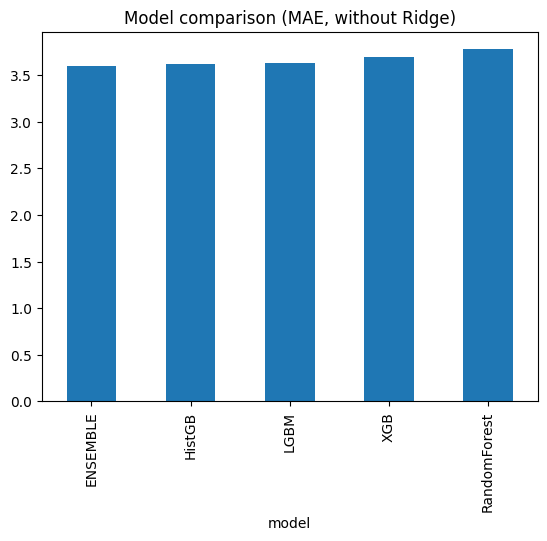

In [11]:
plot_df = results_df[results_df["model"] != "Ridge"]

plot_df.set_index("model")["MAE"].plot.bar()
plt.title("Model comparison (MAE, without Ridge)")
plt.show()

## Model mentése

In [12]:
best_model_name = results_df.iloc[0]["model"]

if best_model_name == "ENSEMBLE":
    best_model = ensemble_models
else:
    best_model = trained_models[best_model_name]

joblib.dump(best_model, "../models/model.pkl")
print(f"Best model = {best_model_name} saved.")

top_trained_models = {
    name: trained_models[name]
    for name in top_models
}

joblib.dump(top_trained_models, ENSEMBLE_PATH)
print("Top-2 ensemble saved.")

Best model = ENSEMBLE saved.
Top-2 ensemble saved.


## Metrikák

In [13]:
print(f"\nBest model: {best_model_name}")

if best_model_name == "ENSEMBLE":

    # --- TRAIN ---
    train_preds = []
    for m in best_model.values():
        p = np.maximum(0, np.expm1(m.predict(X_train)))
        train_preds.append(p)
    train_pred = np.mean(train_preds, axis=0)

    # --- TEST ---
    test_preds = []
    for m in best_model.values():
        p = np.maximum(0, np.expm1(m.predict(X_test)))
        test_preds.append(p)
    test_pred = np.mean(test_preds, axis=0)

else:

    # --- TRAIN ---
    train_pred_log = best_model.predict(X_train)
    train_pred = np.maximum(0, np.expm1(train_pred_log))

    # --- TEST ---
    test_pred_log  = best_model.predict(X_test)
    test_pred = np.maximum(0, np.expm1(test_pred_log))

    
# --- METRICS ---
train_mae = mean_absolute_error(y_train, train_pred)
test_mae  = mean_absolute_error(y_test, test_pred)

train_r2 = r2_score(y_train, train_pred)
test_r2  = r2_score(y_test, test_pred)

print("\n=== OVERFITTING CHECK ===")
print(f"Train MAE: {train_mae:.3f}", "µg/m³")
print(f"Test  MAE: {test_mae:.3f}", "µg/m³")
print(f"Train R2 : {train_r2:.3f}")
print(f"Test  R2 : {test_r2:.3f}")


Best model: ENSEMBLE

=== OVERFITTING CHECK ===
Train MAE: 1.931 µg/m³
Test  MAE: 3.595 µg/m³
Train R2 : 0.893
Test  R2 : 0.887


A train és test eredmények hasonlósága nem utal erős overfittingre és jó egyensúlyt talál a bias(torzítás) és variance(szórás) között.<br>

Ha nagyon különbözik a train és teszt eredmény, akkor magas variance (overfitting) áll fenn. Vagyis a model nagyon "rátanult" az adatokra.<br>
Ha mindkettő rossz magas bias (underfitting), a modell túl egyszerű.<br>

# Eredmény

A vizsgált modellek közül az ensemble modell érte el a legjobb teljesítményt, azonban az LGBMRegressor és a HistGradientBoosting eredményei nagyon közel állnak hozzá, ami azt mutatja, hogy a gradient boosting alapú módszerek különösen jól működnek ezen a feladaton.

A RandomForest és az XGBoost gyengébb teljesítményt mutattak, míg a Ridge regresszió jelentősen alulteljesített.

A train és test metrikák hasonlósága alapján nem figyelhető meg erős overfitting.

Az eredmények alapján a gradient boosting modellek tekinthetők a legalkalmasabbnak erre a problémára, és ezek kombinációja ensemble formájában biztosítja a legjobb és legstabilabb teljesítményt, ezért a továbbiakban az ensemble modellt alkalmazzuk.